# Customer Segmentation with RFM Analysis

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **Customer Value and Retention** and contains the computational implementation of the customer segmentation workflow developed using transactional data from the AdventureWorks database.

The objective is to identify meaningful customer groups based on purchasing behavior and to establish a quantitative foundation for the churn prediction and customer lifetime value (CLV) models developed later in the project.

The analysis begins with the construction of Recency, Frequency, and Monetary Value (RFM) features, followed by exploratory analysis, customer scoring, and customer segmentation using K-Means clustering. The number of segments is not fixed in advance; instead, it is evaluated using clustering diagnostics such as inertia, silhouette score, Calinski-Harabasz score, and Davies-Bouldin score.

In addition to customer segmentation, the notebook introduces a continuous intra-cluster scoring framework designed to rank customers within each segment according to their relative behavioral importance. This additional layer of analysis provides a practical mechanism for prioritization once customer groups have been identified.

The notebook emphasizes reproducibility, interpretability, and practical decision-making. The focus is not only on obtaining statistically sound segments, but also on understanding how those segments can support customer retention, marketing actions, and long-term value creation.

## Objectives

The specific objectives of this notebook are:

1. Extract and prepare customer transaction data from the AdventureWorks database.
2. Construct customer-level RFM features.
3. Explore purchasing behavior across customers, products, and territories.
4. Develop a continuous RFM scoring framework.
5. Identify customer segments using K-Means clustering.
6. Evaluate alternative numbers of clusters using clustering validation metrics.
7. Profile and interpret the resulting customer segments.
8. Rank customers within each segment using an intra-cluster scoring methodology.
9. Generate actionable insights to support retention and customer value strategies.

## Libraries and Configuration

This section imports the libraries used throughout the analysis and defines a small set of configuration options to improve reproducibility and visualization quality.

The project relies primarily on:

- Pandas and NumPy for data manipulation.
- SQLAlchemy for database connectivity.
- Matplotlib and Seaborn for visualization.
- SciPy for statistical transformations.
- Scikit-Learn for preprocessing, dimensionality reduction, K-Means clustering, and clustering evaluation.

The implementation is intentionally kept simple. The objective is not to test every possible clustering algorithm, but to build a clear and reproducible customer segmentation workflow that can be explained and used in practice.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Database connectivity
from sqlalchemy import create_engine

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical transformations
from scipy.stats import boxcox

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans

# Clustering evaluation
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Miscellaneous
from pathlib import Path
import warnings

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

sns.set_theme(style="whitegrid")

## Database Connection

The AdventureWorks database is hosted locally in PostgreSQL.

Credentials are requested at runtime to avoid storing sensitive information directly in the notebook.

In [3]:
from getpass import getpass
from sqlalchemy.engine import URL
from sqlalchemy import create_engine

In [4]:
db_user = input("Username: ")
db_password = getpass("Password: ")

Username:  postgres
Password:  ········


In [5]:
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host="localhost",
    port=5432,
    database="adventureworks",
)

engine = create_engine(connection_url)

In [6]:
query = """
SELECT
    current_database() AS database_name,
    current_user AS user_name,
    current_setting('server_encoding') AS server_encoding,
    current_setting('client_encoding') AS client_encoding;
"""

pd.read_sql(query, engine)

,database_name,user_name,server_encoding,client_encoding
0,adventureworks,postgres,UTF8,UTF8


## Data Extraction

The analysis uses a simplified customer analytics model built from the AdventureWorks transactional database.

The original database contains many operational tables. For this project, only the tables required to describe customers, orders, products, categories, and sales territories are extracted.

This keeps the analytical dataset focused on the business question: how customers purchase, how valuable they are, and how they can be grouped based on observed behaviour.

### Customer Analytics Data Model

The customer segmentation workflow is based on the following core entities:

- `sales.customer`
- `sales.salesorderheader`
- `sales.salesorderdetail`
- `production.product`
- `production.productsubcategory`
- `production.productcategory`
- `sales.salesterritory`

The simplified ERD below documents the subset of AdventureWorks used in this notebook.

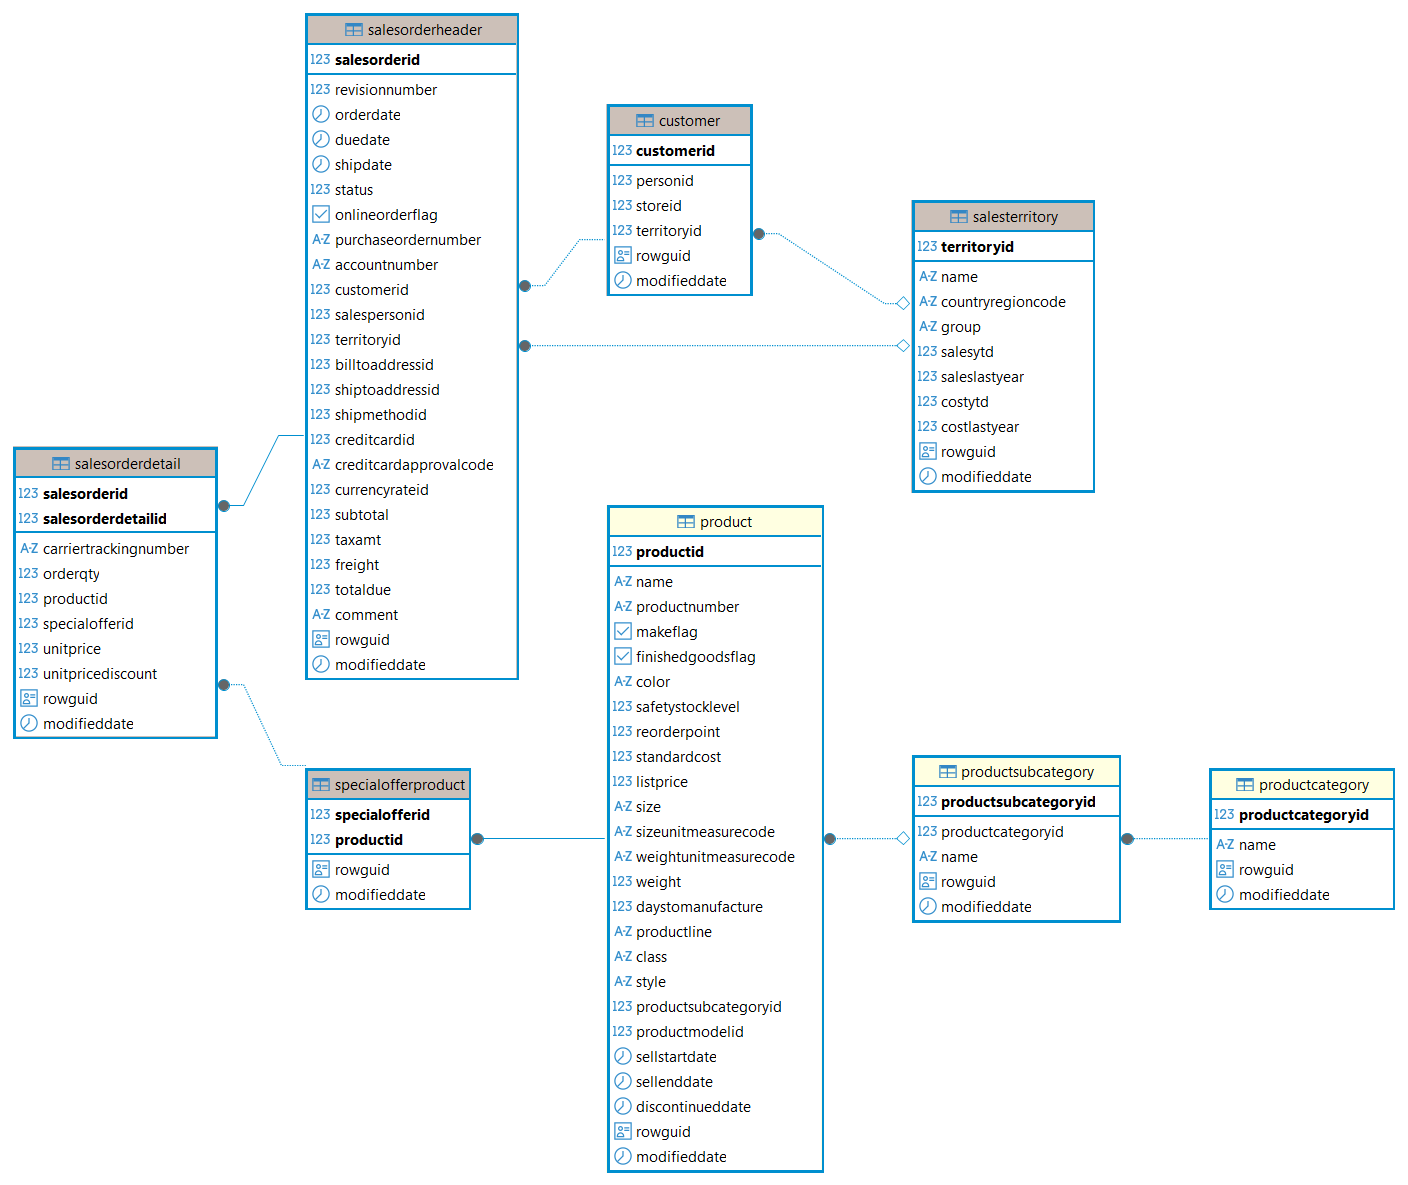

In [7]:
from IPython.display import Image, display

erd_path = Path("../data/customer-analytics-erd.png")

display(Image(filename=erd_path))

### Extract Transactional Data

The query below extracts order-level and product-level transaction data.

Each row represents one product line within a customer order. This level of detail is useful because it allows the analysis to aggregate customer behaviour in different ways, including total spend, number of orders, number of purchased items, and product category diversity.

In [8]:
query = """
SELECT
    c.customerid AS customer_id,
    soh.salesorderid AS sales_order_id,
    soh.orderdate AS order_date,
    soh.duedate AS due_date,
    soh.shipdate AS ship_date,
    soh.status AS order_status,
    soh.territoryid AS territory_id,
    st.name AS territory_name,
    st.countryregioncode AS country_region_code,
    sod.salesorderdetailid AS sales_order_detail_id,
    sod.productid AS product_id,
    p.name AS product_name,
    pc.name AS product_category,
    ps.name AS product_subcategory,
    sod.orderqty AS order_quantity,
    sod.unitprice AS unit_price,
    sod.unitpricediscount AS unit_price_discount,
    (
        sod.orderqty
        * sod.unitprice
        * (1 - sod.unitpricediscount)
    ) AS line_total
FROM sales.customer AS c
INNER JOIN sales.salesorderheader AS soh
    ON c.customerid = soh.customerid
INNER JOIN sales.salesorderdetail AS sod
    ON soh.salesorderid = sod.salesorderid
INNER JOIN production.product AS p
    ON sod.productid = p.productid
LEFT JOIN production.productsubcategory AS ps
    ON p.productsubcategoryid = ps.productsubcategoryid
LEFT JOIN production.productcategory AS pc
    ON ps.productcategoryid = pc.productcategoryid
LEFT JOIN sales.salesterritory AS st
    ON soh.territoryid = st.territoryid;
"""

transactions = pd.read_sql(query, engine)

In [9]:
transactions.head()

,customer_id,sales_order_id,order_date,due_date,ship_date,order_status,territory_id,territory_name,country_region_code,sales_order_detail_id,product_id,product_name,product_category,product_subcategory,order_quantity,unit_price,unit_price_discount,line_total
0,29825,43659,2022-05-30,2022-06-11,2022-06-06,5,5,Southeast,US,1,776,"Mountain-100 Black, 42",Bikes,Mountain Bikes,1,2024.994,0.0,2024.994
1,29825,43659,2022-05-30,2022-06-11,2022-06-06,5,5,Southeast,US,2,777,"Mountain-100 Black, 44",Bikes,Mountain Bikes,3,2024.994,0.0,6074.982
2,29825,43659,2022-05-30,2022-06-11,2022-06-06,5,5,Southeast,US,3,778,"Mountain-100 Black, 48",Bikes,Mountain Bikes,1,2024.994,0.0,2024.994
3,29825,43659,2022-05-30,2022-06-11,2022-06-06,5,5,Southeast,US,4,771,"Mountain-100 Silver, 38",Bikes,Mountain Bikes,1,2039.994,0.0,2039.994
4,29825,43659,2022-05-30,2022-06-11,2022-06-06,5,5,Southeast,US,5,772,"Mountain-100 Silver, 42",Bikes,Mountain Bikes,1,2039.994,0.0,2039.994


In [10]:
transactions.shape

(121317, 18)

### Initial Data Inspection

The extracted dataset contains one row per product line within a customer order.

Before moving into feature engineering, a few basic checks are performed to validate the structure of the data: dimensions, data types, missing values, duplicated rows, date range, and high-level transaction totals.

In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            121317 non-null  int64         
 1   sales_order_id         121317 non-null  int64         
 2   order_date             121317 non-null  datetime64[ns]
 3   due_date               121317 non-null  datetime64[ns]
 4   ship_date              121317 non-null  datetime64[ns]
 5   order_status           121317 non-null  int64         
 6   territory_id           121317 non-null  int64         
 7   territory_name         121317 non-null  object        
 8   country_region_code    121317 non-null  object        
 9   sales_order_detail_id  121317 non-null  int64         
 10  product_id             121317 non-null  int64         
 11  product_name           121317 non-null  object        
 12  product_category       121317 non-null  obje

In [12]:
transactions.isna().sum().sort_values(ascending=False)

customer_id              0
sales_order_id           0
unit_price_discount      0
unit_price               0
order_quantity           0
product_subcategory      0
product_category         0
product_name             0
product_id               0
sales_order_detail_id    0
country_region_code      0
territory_name           0
territory_id             0
order_status             0
ship_date                0
due_date                 0
order_date               0
line_total               0
dtype: int64

In [13]:
transactions.duplicated().sum()

0

In [14]:
transactions["order_date"].agg(["min", "max"])

min   2022-05-30
max   2025-06-29
Name: order_date, dtype: datetime64[ns]

In [15]:
summary = pd.Series({
    "order_lines": len(transactions),
    "customers": transactions["customer_id"].nunique(),
    "orders": transactions["sales_order_id"].nunique(),
    "products": transactions["product_id"].nunique(),
    "territories": transactions["territory_id"].nunique(),
    "total_revenue": transactions["line_total"].sum()
})

summary

order_lines      1.213170e+05
customers        1.911900e+04
orders           3.146500e+04
products         2.660000e+02
territories      1.000000e+01
total_revenue    1.098464e+08
dtype: float64

In [16]:
inspection_summary = pd.DataFrame({
    "Metric": [
        "Order Lines",
        "Customers",
        "Orders",
        "Products",
        "Territories",
        "Total Revenue"
    ],
    "Value": [
        transactions.shape[0],
        transactions["customer_id"].nunique(),
        transactions["sales_order_id"].nunique(),
        transactions["product_id"].nunique(),
        transactions["territory_id"].nunique(),
        round(transactions["line_total"].sum(), 2)
    ]
})

inspection_summary

,Metric,Value
0,Order Lines,121317.0
1,Customers,19119.0
2,Orders,31465.0
3,Products,266.0
4,Territories,10.0
5,Total Revenue,109846381.4


## Exploratory Data Analysis

Before constructing customer-level features, it is useful to understand the overall structure of the transactional data.

This exploratory analysis focuses on three questions:

- How have sales evolved over time?
- How are purchases distributed across customers?
- Which products and territories contribute most to revenue?

The goal is not to perform an exhaustive exploratory analysis, but rather to develop a practical understanding of the customer base before building segmentation features.

### Sales Overview

The first step is to examine the evolution of sales activity over time.

Monthly revenue, order volume, and customer activity provide a useful high-level view of the business and help identify potential seasonality, growth patterns, or structural changes in purchasing behaviour.

In [17]:
monthly_sales = (
    transactions
    .groupby(
        pd.Grouper(
            key="order_date",
            freq="M"
        )
    )
    .agg(
        revenue=("line_total", "sum"),
        orders=("sales_order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head()

,order_date,revenue,orders,customers
0,2022-05-31,5.177374e+05,47,47
1,2022-06-30,2.001279e+06,217,217
2,2022-07-31,1.668510e+06,215,215
3,2022-08-31,1.326138e+06,189,189
4,2022-09-30,2.836410e+06,250,250


In [18]:
monthly_sales.describe()

,order_date,revenue,orders,customers
count,38,3.800000e+01,38.000000,38.000000
mean,2023-12-15 10:06:18.947368448,2.890694e+06,828.026316,809.052632
min,2022-05-31 00:00:00,4.749155e+04,47.000000,47.000000
25%,2023-03-07 18:00:00,2.020157e+06,268.250000,268.250000
50%,2023-12-15 12:00:00,2.832907e+06,384.000000,384.000000
75%,2024-09-22 12:00:00,3.537947e+06,1777.500000,1715.750000
max,2025-06-30 00:00:00,5.222759e+06,2304.000000,2246.000000
std,NaN,1.282789e+06,792.615223,765.058484


In [19]:
monthly_sales_plot = monthly_sales[
    monthly_sales["order_date"] < "2025-06-01"
].copy()

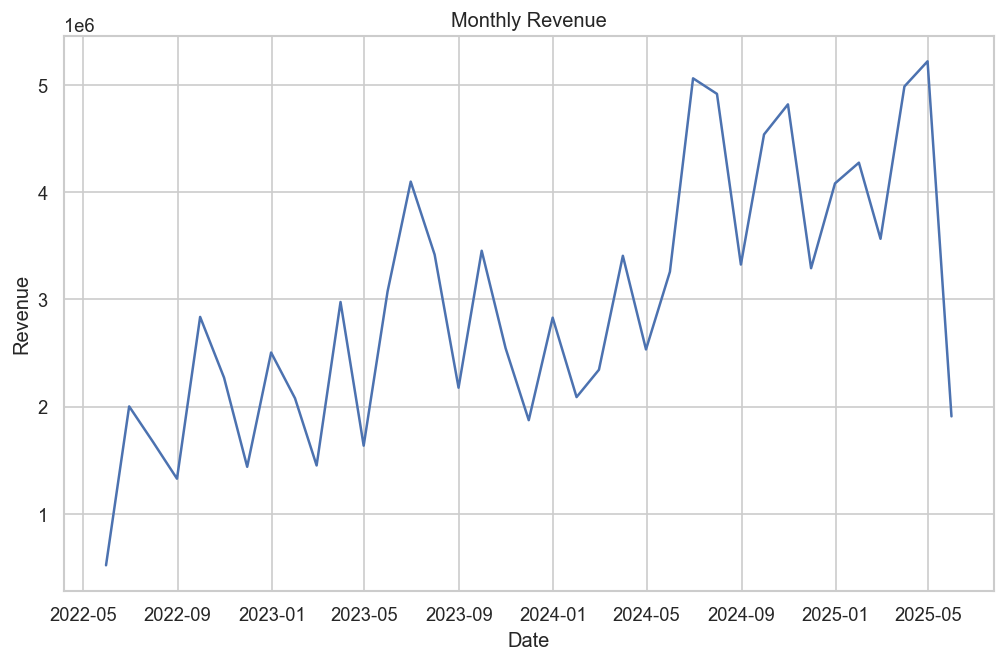

In [20]:
fig, ax = plt.subplots()

ax.plot(
    monthly_sales_plot["order_date"],
    monthly_sales_plot["revenue"]
)

ax.set_title("Monthly Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")

plt.show()

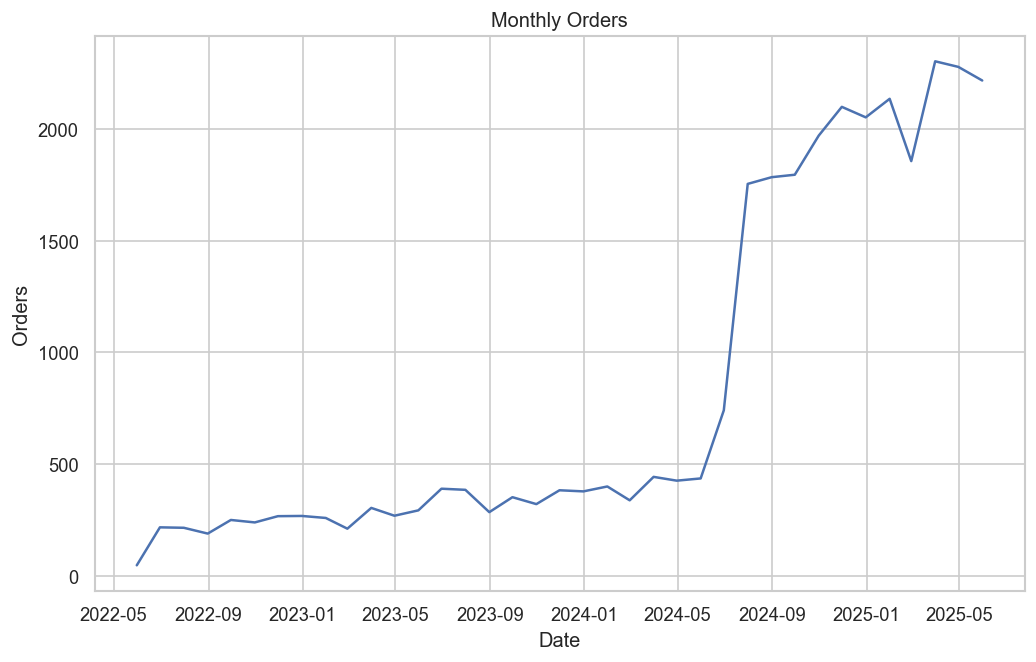

In [21]:
fig, ax = plt.subplots()

ax.plot(
    monthly_sales_plot["order_date"],
    monthly_sales_plot["orders"]
)

ax.set_title("Monthly Orders")
ax.set_xlabel("Date")
ax.set_ylabel("Orders")

plt.show()

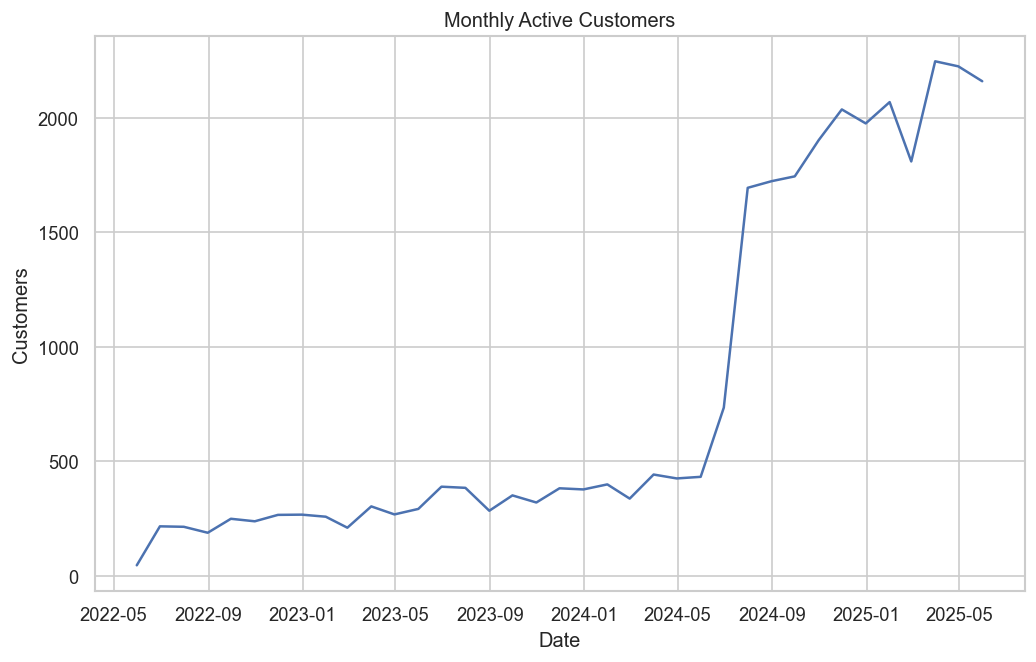

In [22]:
fig, ax = plt.subplots()

ax.plot(
    monthly_sales_plot["order_date"],
    monthly_sales_plot["customers"]
)

ax.set_title("Monthly Active Customers")
ax.set_xlabel("Date")
ax.set_ylabel("Customers")

plt.show()

### Customer Composition

Before constructing customer-level features, it is useful to understand the composition of the customer base.

AdventureWorks contains both individual consumers and commercial customers. Understanding the relative contribution of each group provides additional context for interpreting the segmentation results.

In [23]:
query = """
SELECT
    CASE
        WHEN personid IS NOT NULL THEN 'Individual'
        WHEN storeid IS NOT NULL THEN 'Store'
        ELSE 'Unknown'
    END AS customer_type,
    COUNT(*) AS customers
FROM sales.customer
GROUP BY customer_type
ORDER BY customers DESC;
"""

customer_types = pd.read_sql(query, engine)

customer_types

,customer_type,customers
0,Individual,19119
1,Store,701


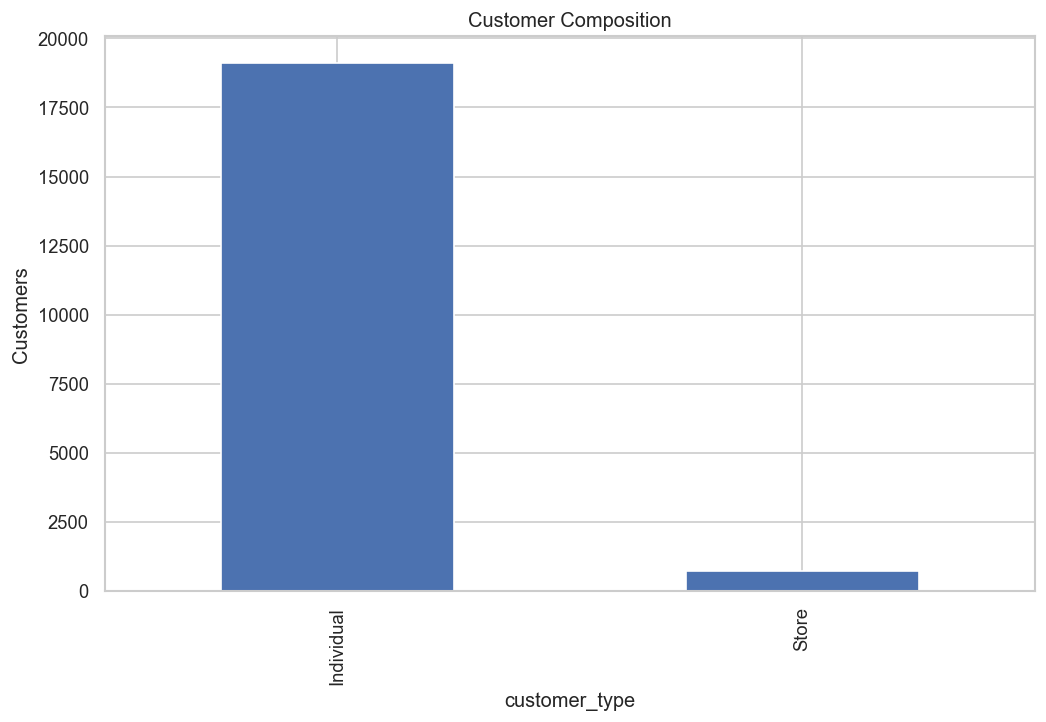

In [24]:
customer_types.plot(
    kind="bar",
    x="customer_type",
    y="customers",
    legend=False
)

plt.title("Customer Composition")
plt.ylabel("Customers")

plt.show()

## RFM Feature Engineering

Customer segmentation begins with the construction of Recency, Frequency, and Monetary Value (RFM) variables.

These variables summarize customer purchasing behaviour from three complementary perspectives:

- Recency measures how recently a customer has placed an order.
- Frequency measures how often a customer purchases.
- Monetary Value measures the total amount spent by the customer.

Together, these variables provide a compact representation of customer engagement and value, making them a natural starting point for segmentation analysis.

### Reference Date

Recency is calculated relative to a fixed reference date corresponding to the most recent transaction observed in the dataset.

Using a common reference date ensures that recency values are comparable across all customers.

In [25]:
reference_date = (
    transactions["order_date"].max()
    + pd.Timedelta(days=1)
)

reference_date

Timestamp('2025-06-30 00:00:00')

### Customer-Level Aggregation

The transactional dataset is aggregated at the customer level to construct the Recency, Frequency, and Monetary Value variables.

The resulting dataset contains one row per customer and forms the basis for all subsequent segmentation analyses.

In [26]:
rfm = (
    transactions
    .groupby("customer_id")
    .agg(
        recency=(
            "order_date",
            lambda x: (
                reference_date - x.max()
            ).days
        ),
        frequency=(
            "sales_order_id",
            "nunique"
        ),
        monetary=(
            "line_total",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,11000,271,3,8248.99
1,11001,50,3,6383.88
2,11002,340,3,8114.04
3,11003,264,3,8139.29
4,11004,273,3,8196.01


In [27]:
rfm.shape

(19119, 4)

### Distribution of RFM Variables

Before applying any transformation, it is useful to inspect the empirical distributions of the RFM variables.

Customer transaction data often exhibits strong asymmetry, particularly for Frequency and Monetary Value. A small proportion of customers tend to account for a large share of transactions and revenue, producing highly skewed distributions.

Understanding these patterns helps motivate the transformations applied later in the workflow.

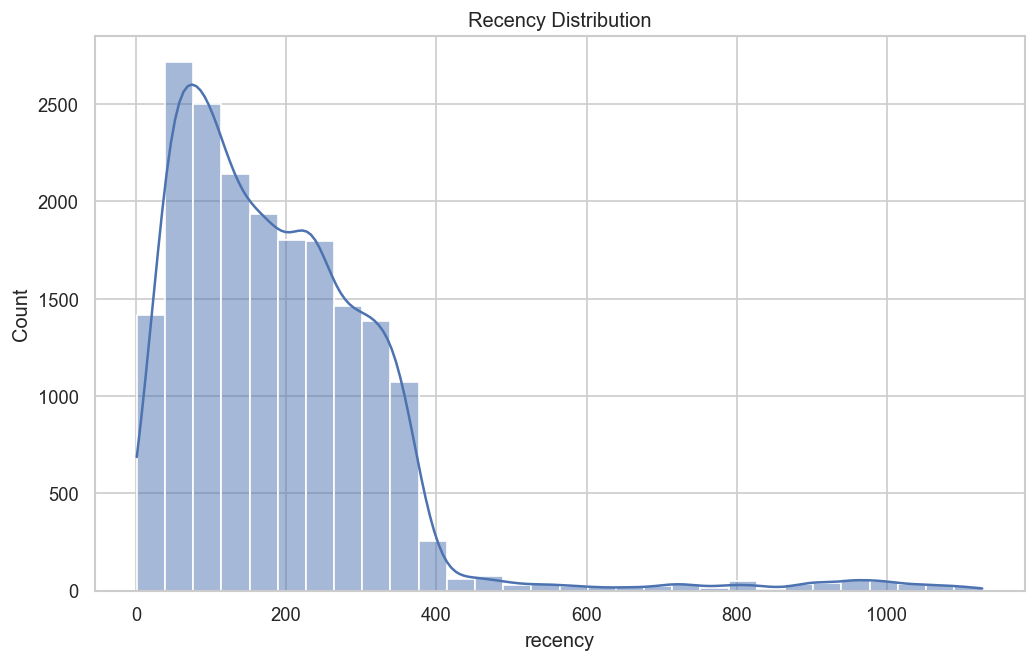

In [28]:
fig, ax = plt.subplots()

sns.histplot(
    rfm["recency"],
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Recency Distribution")

plt.show()

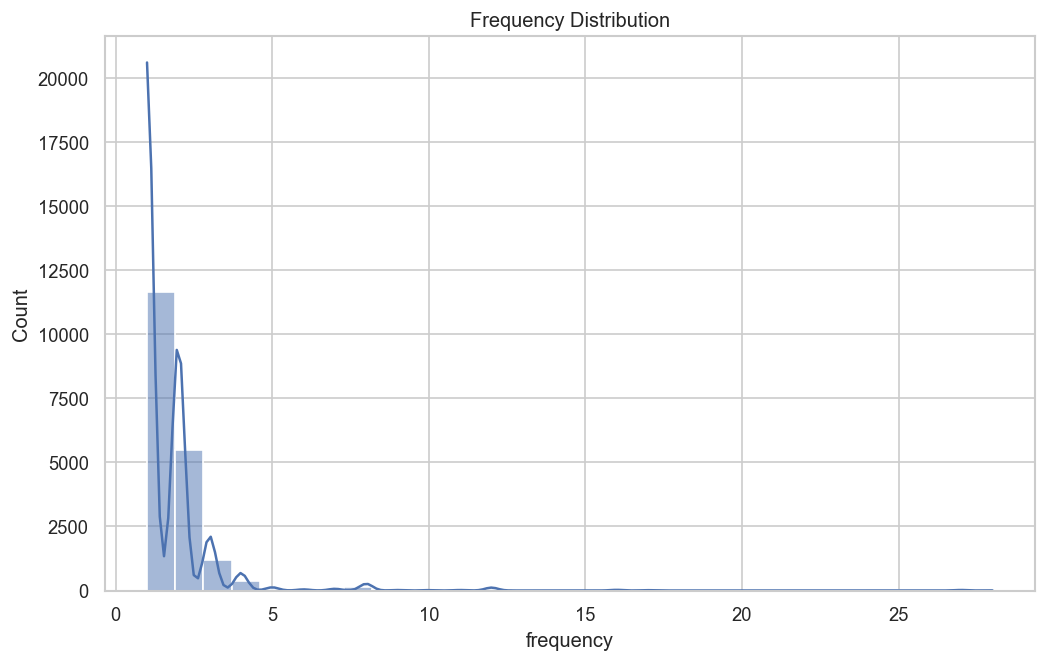

In [29]:
fig, ax = plt.subplots()

sns.histplot(
    rfm["frequency"],
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Frequency Distribution")

plt.show()

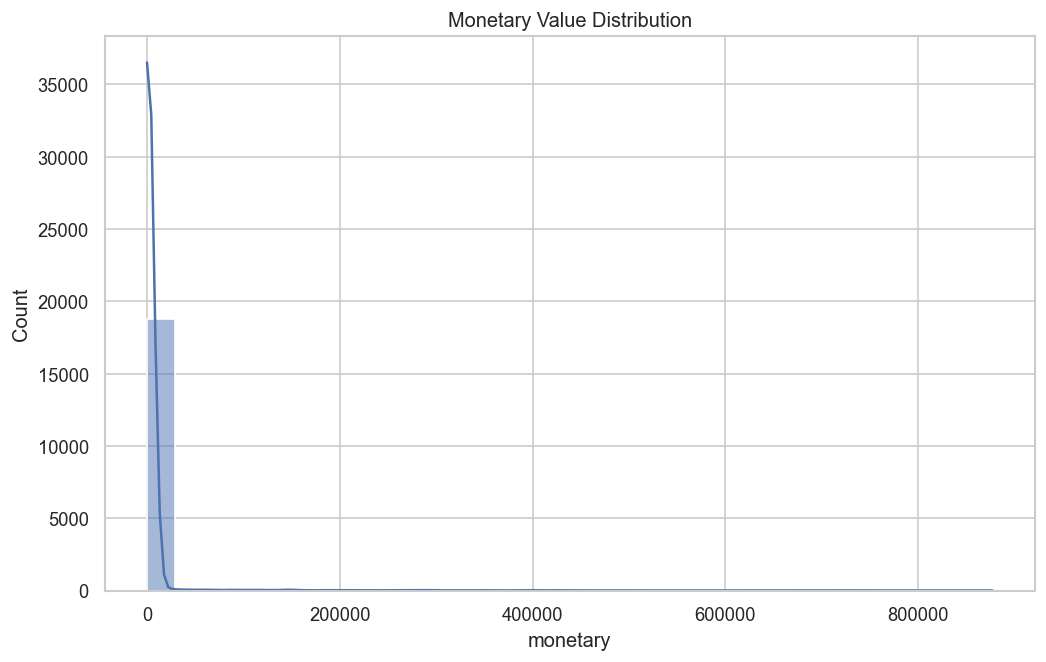

In [30]:
fig, ax = plt.subplots()

sns.histplot(
    rfm["monetary"],
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Monetary Value Distribution")

plt.show()

In [31]:
rfm[["recency", "frequency", "monetary"]].skew()

recency       2.435350
frequency     7.388770
monetary     12.798424
dtype: float64